In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
import random

## Dependencies
  - python=3.12
  - pytorch
  - torchvision
  - torchaudio
  - pytorch-cuda=11.8
  - jupyter
  - scikit-learn
  - matplotlib
  - seaborn
  - pillow
  - numpy

## For Reproducibility


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Hardware specifications

In [3]:
import platform

if torch.cuda.is_available():
    # For CUDA-capable systems
    !nvidia-smi
elif torch.backends.mps.is_available():
    # For macOS with Apple Silicon
    print("MPS (Apple Silicon) is available.")
    print("macOS Version:", platform.mac_ver()[0])
    print("Torch MPS support:", torch.backends.mps.is_available())
else:
    print("Using CPU.")


Thu May  8 17:11:57 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 576.28                 Driver Version: 576.28         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   42C    P8              1W /   85W |       0MiB /   6141MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# --- DEVICE ---
if torch.cuda.is_available():
    device = torch.device("cuda")  # NVIDIA GPU
elif torch.backends.mps.is_available():
    device = torch.device("mps")   # Apple M1/M2/M3/M4 GPU
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


## Preprocessing helmet image dataset
Removing the exact same images from the dataset we collected to prevent overfitting.

In [13]:
# import os
# import hashlib

# def remove_exact_duplicates(folder_path):
#     seen = set()
#     removed = 0

#     for subdir, _, files in os.walk(folder_path):
#         for file in files:
#             path = os.path.join(subdir, file)
#             try:
#                 with open(path, 'rb') as f:
#                     file_hash = hashlib.md5(f.read()).hexdigest()
#                 if file_hash in seen:
#                     os.remove(path)
#                     removed += 1
#                 else:
#                     seen.add(file_hash)
#             except Exception as e:
#                 print(f"Error processing {path}: {e}")

#     print(f"Removed {removed} exact duplicate image(s).")

# remove_exact_duplicates("helmet_dataset")


In [5]:
# --- SETTINGS ---
dataset_path = "helmet_dataset"
image_size = 300 # EfficientNet uses 300x300 input size
# batch_size = 8
# epochs = 15
# lr = 0.0003
print(os.listdir("helmet_dataset"))

['.DS_Store', 'looking', 'not_looking']


In [6]:
# --- SAFETY LOADER ---
def pil_loader(path):
    with open(path, 'rb') as f:
        img = Image.open(f)
        return img.convert('RGB')

In [7]:
# --- TRANSFORM ---
train_transform = transforms.Compose([
    transforms.Resize((320, 320)),              # Resize slightly bigger
    transforms.CenterCrop(300),                 # Crop to model input
    transforms.RandomHorizontalFlip(p=0.5),     # Good if left/right isn’t label-dependent
    transforms.RandomRotation(10),              # Small tilt variation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.CenterCrop(300),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


**Resizing** - Is done to ensure consistent input dimensions for the CNN. This also reduces computational load.

**RandomHorizontalFlip** - This simulates real-world variations (e.g., helmet on left/right side) and helps the model generalize better. Also, since  orientation doesn't affect the label. 

**Random Rotation** - This makes the model more robust to viewpoint changes in real-world usage.

**Normalization** - We used ImageNet-standard mean and standard deviation for normalization. This centers the input distributions and improves training convergence. Even though we trained from scratch, these values are widely used and provide good baseline behavior.

**ToTensor()** - So that the images are compatible with PyTorch

For the **Validation Set** we do not apply augmentation but just resizing and normalization for consistent evaluation without any artifical modifications.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


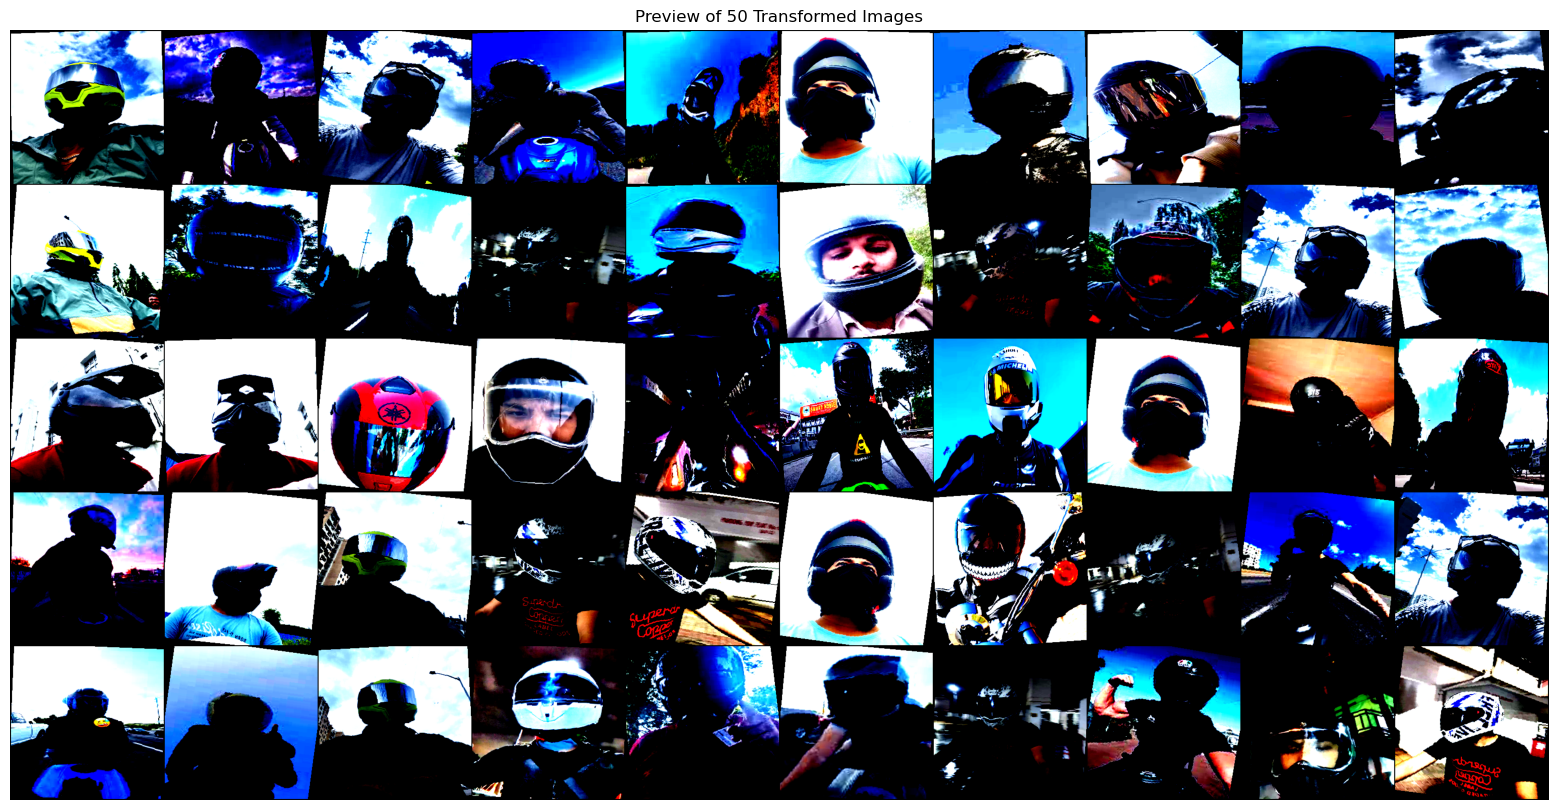

In [8]:
import torchvision

# Load dataset with transform applied
preview_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform,
    loader=pil_loader
)

# Create a DataLoader (no shuffling)
preview_loader = DataLoader(preview_dataset, batch_size=50, shuffle=True)

# Get one batch
images, labels = next(iter(preview_loader))

# Make a grid of 50 images (5 rows × 10 columns)
grid_img = torchvision.utils.make_grid(images[:50], nrow=10, padding=2)

# Unnormalize if needed (for display only)
np_img = grid_img.permute(1, 2, 0).numpy()

# Show the image grid
plt.figure(figsize=(20, 10))
plt.imshow(np_img)
plt.axis('off')
plt.title("Preview of 50 Transformed Images")
plt.show()

## Preparing Dataset

In [9]:
import shutil

# Delete any .ipynb_checkpoints inside helmet_dataset
checkpoints_path = os.path.join(dataset_path, ".ipynb_checkpoints")
if os.path.exists(checkpoints_path):
    shutil.rmtree(checkpoints_path)
    print("Removed .ipynb_checkpoints folder.")

In [10]:
# --- DATASET ---
def is_valid_image(path):
    return not any(x in path for x in ['.DS_Store', '.ipynb_checkpoints'])
    
dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=None,
    loader=pil_loader,
    is_valid_file=is_valid_image
)

print("Classes:", dataset.classes)
print("Class-to-index:", dataset.class_to_idx)

Classes: ['looking', 'not_looking']
Class-to-index: {'looking': 0, 'not_looking': 1}


In [11]:
from sklearn.model_selection import StratifiedShuffleSplit
from collections import Counter

# Use full dataset (700 images)
targets = dataset.targets  # From ImageFolder

In [12]:
# Custom wrapper to apply transform after subset
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.subset)

## Importing and Using SOTA EfficientNet-B3

In [13]:
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
weights = EfficientNet_B3_Weights.DEFAULT

model = efficientnet_b3(weights=weights)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)  # For binary classification
model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to C:\Users\fahre/.cache\torch\hub\checkpoints\efficientnet_b3_rwightman-b3899882.pth
100.0%


## Preparing Smaller Dataset for Fine tuning

In [14]:
subset_size = 300

splitter = StratifiedShuffleSplit(n_splits=1, test_size=(subset_size / len(dataset)), random_state=42)

for small_idx, _ in splitter.split(np.zeros(len(targets)), targets):
    small_dataset = torch.utils.data.Subset(dataset, small_idx)

subset_labels = [dataset.targets[i] for i in small_dataset.indices]
print("Small subset size:", len(small_dataset))
print("Class counts:", Counter(subset_labels))

Small subset size: 404
Class counts: Counter({0: 203, 1: 201})


In [15]:
small_targets = [dataset.targets[i] for i in small_dataset.indices]

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, val_idx in splitter.split(np.zeros(len(small_targets)), small_targets):
    train_dataset = torch.utils.data.Subset(small_dataset, train_idx)
    val_dataset = torch.utils.data.Subset(small_dataset, val_idx)

In [16]:
# Apply transforms
train_dataset = TransformedSubset(train_dataset, train_transform)
val_dataset = TransformedSubset(val_dataset, val_transform)

## Fine tuning using Grid Search

In [18]:
from itertools import product
import time

def train_with_early_stopping(model, train_loader, val_loader, criterion, optimizer, epochs=20, patience=3):
    best_val_loss = float('inf')
    best_model_state = None
    counter = 0

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # Evaluate on validation set
        val_acc, val_loss = evaluate_model(model, val_loader, criterion)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Early stopping logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"⛔ Early stopping at epoch {epoch+1}")
                break

    if best_model_state:
        model.load_state_dict(best_model_state)

    return model, train_losses, train_accuracies, val_losses, val_accuracies

In [20]:
from itertools import product
from tqdm import tqdm
import gc
import time

param_grid = {
    "batch_size": [8, 16, 32],
    "lr": [0.01, 0.001, 0.0001],
    "epochs": [5, 10],
}

all_params = list(product(*param_grid.values()))
param_names = list(param_grid.keys())
results = []

for params in tqdm(all_params, desc="Grid Search"):
    config = dict(zip(param_names, params))
    print(f"\nRunning config: {config}")

    # Data loaders
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'])

    # Model setup
    model = efficientnet_b3(weights=True)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
    model = model.to(device)

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])

    # Train with early stopping
    start = time.time()
    trained_model, train_losses, train_accs, val_losses, val_accs = train_with_early_stopping(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        epochs=config['epochs'],
        patience=3
    )
    end = time.time()

    final_val_acc = val_accs[-1]
    final_val_loss = val_losses[-1]

    print(f"✅ Final Val Acc: {final_val_acc:.4f} | Final Val Loss: {final_val_loss:.4f} | Time: {end - start:.2f}s")

    results.append({
        'batch_size': config['batch_size'],
        'lr': config['lr'],
        'epochs': config['epochs'],
        'val_acc': final_val_acc,
        'val_loss': final_val_loss,
        'train_acc': train_accs[-1],
        'train_loss': train_losses[-1],
        'time': end - start
    })

    # Cleanup
    del model
    del trained_model
    torch.cuda.empty_cache()
    gc.collect()

ModuleNotFoundError: No module named 'tqdm'

In [ ]:
best = max(results, key=lambda x: x['val_acc'])
print(f"\nBest Config: {best}")

## Training the model with best hyperparameter

Using the whole dataset to train the model with the best hyperparameter.

**Model**: Custom 3-layer CNN

Final Hyperparameters:
* Learning Rate: 0.001
* Batch Size: 32
* Epochs: 10
* Optimizer: Adam
* Loss Function: CrossEntropyLoss

In [16]:
best_config = {
    'lr': 0.001,
    'optimizer': 'Adam',
    'batch_size': 32,
    'epochs': 15
}

In [17]:
# Prepare full dataset, dividing into testing and training.
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

for train_idx, val_idx in splitter.split(np.zeros(len(targets)), targets):
    train_dataset = torch.utils.data.Subset(dataset, train_idx)
    val_dataset = torch.utils.data.Subset(dataset, val_idx)

print("Train set size:", len(train_dataset))
print("Val set size:", len(val_dataset))

train_labels = [dataset.targets[i] for i in train_dataset.indices]
val_labels = [dataset.targets[i] for i in val_dataset.indices]
print("Train class counts:", Counter(train_labels))
print("Val class counts:", Counter(val_labels))

Train set size: 492
Val set size: 212
Train class counts: Counter({0: 247, 1: 245})
Val class counts: Counter({0: 106, 1: 106})


In [18]:
# Apply transforms
full_train_dataset = TransformedSubset(train_dataset, train_transform)
full_val_dataset = TransformedSubset(val_dataset, val_transform)

In [19]:
train_loader = DataLoader(full_train_dataset, batch_size=best_config['batch_size'], shuffle=True)
val_loader = DataLoader(full_val_dataset, batch_size=best_config['batch_size'], shuffle=False)

In [38]:
model = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=best_config['lr'])

In [39]:
# --- METRICS TRACKING ---
train_losses = []
train_accuracies = []
val_accuracies = []
val_losses = []

In [40]:
def trainAndEval(epochs):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
    
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
    
            outputs = model(images)
            loss = criterion(outputs, labels)
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item() * images.size(0)
    
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
    
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
    
        # --- VALIDATION ---
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []
    
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
    
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
                val_loss += criterion(outputs, labels).item() * images.size(0)
    
        accuracy = 100 * correct / total
        loss = val_loss/len(val_loader.dataset)
        
        val_losses.append(loss)
        val_accuracies.append(accuracy)
    
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f} - Train Acc: {epoch_acc:.4f} - Val Loss: {loss:.4f} - Val Acc: {accuracy:.4f}%")

trainAndEval(10)

Epoch 1/10 - Train Loss: 0.9135 - Train Acc: 0.5488 - Val Loss: 0.6837 - Val Acc: 66.0377%
Epoch 2/10 - Train Loss: 0.6569 - Train Acc: 0.6362 - Val Loss: 0.6269 - Val Acc: 65.0943%
Epoch 3/10 - Train Loss: 0.6116 - Train Acc: 0.6585 - Val Loss: 0.5989 - Val Acc: 67.9245%
Epoch 4/10 - Train Loss: 0.5666 - Train Acc: 0.7114 - Val Loss: 0.5602 - Val Acc: 72.1698%
Epoch 5/10 - Train Loss: 0.5257 - Train Acc: 0.7256 - Val Loss: 0.5477 - Val Acc: 73.5849%
Epoch 6/10 - Train Loss: 0.4793 - Train Acc: 0.7622 - Val Loss: 0.5530 - Val Acc: 72.6415%
Epoch 7/10 - Train Loss: 0.4287 - Train Acc: 0.8028 - Val Loss: 0.4907 - Val Acc: 75.0000%
Epoch 8/10 - Train Loss: 0.4043 - Train Acc: 0.8028 - Val Loss: 0.4680 - Val Acc: 75.9434%
Epoch 9/10 - Train Loss: 0.3441 - Train Acc: 0.8557 - Val Loss: 0.4416 - Val Acc: 80.1887%
Epoch 10/10 - Train Loss: 0.2893 - Train Acc: 0.8841 - Val Loss: 0.4812 - Val Acc: 76.8868%


## Evaluation and Anaylsis

In [41]:
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=dataset.classes))


Classification Report:
              precision    recall  f1-score   support

     looking       0.82      0.74      0.78       106
 not_looking       0.76      0.84      0.80       106

    accuracy                           0.79       212
   macro avg       0.79      0.79      0.79       212
weighted avg       0.79      0.79      0.79       212



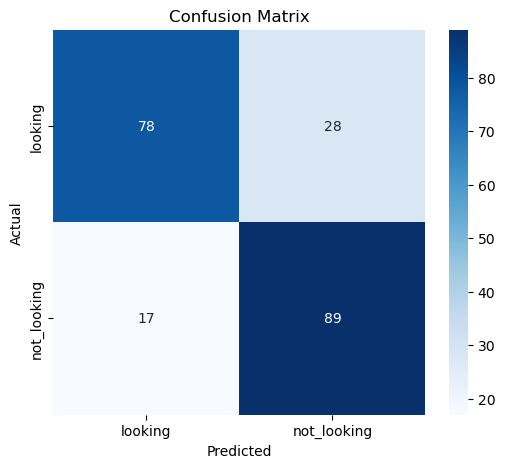

In [42]:
# --- CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

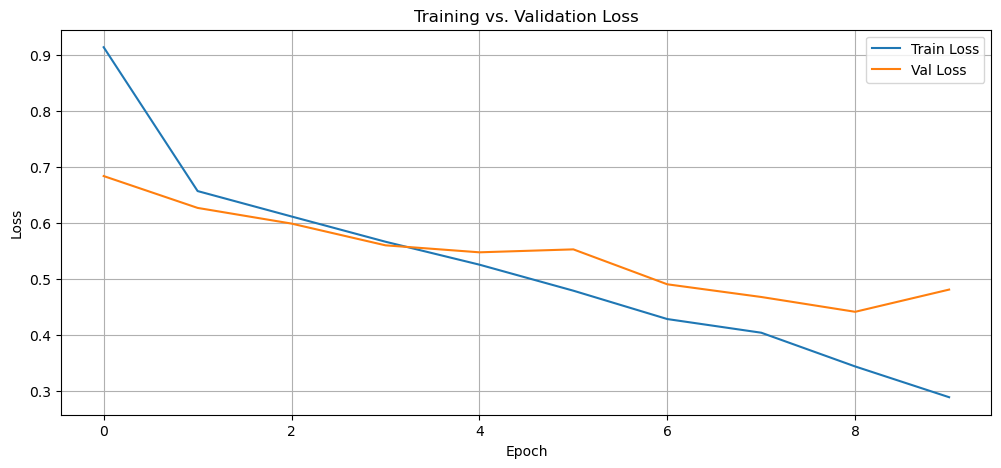

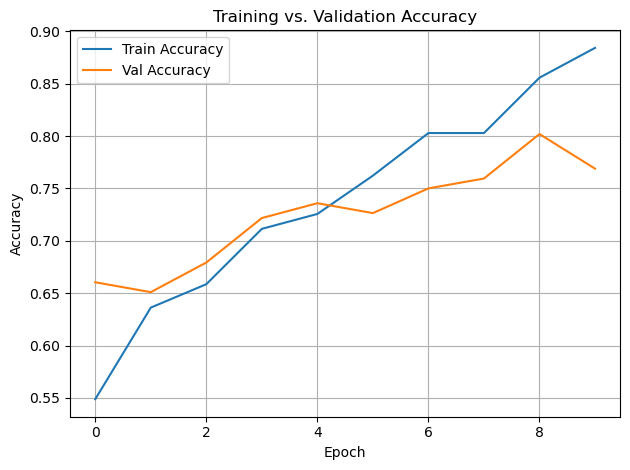

In [43]:
# --- PLOTS ---
plt.figure(figsize=(12, 5))

# Train loss
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Train accuracy
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot([acc / 100 for acc in val_accuracies], label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs. Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show

plt.tight_layout()
plt.show()

In [44]:
# Notes: Trained with 15 epochs validation accuracy starts to drop after epoch 10, so we will stick with 10 epochs.

In [45]:
torch.save(model.state_dict(), "three_layer_cnn.pth")